In [1]:
import random, math
from CriticalNodes import CriticalEdge, CriticalEdges
import pickle

import sys
sys.path.append('../')
from util import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Imports finished.")

Imports finished.


In [2]:
max_rate = 0.35
ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]

In [3]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

In [4]:
def get_deg_diff(ce):
    deg_diffs = []
    for edge in ce.edges:
        deg_diffs.append(abs(edge.node1.degree - edge.node2.degree))
    
    return np.mean(deg_diffs)

def get_homo_diff(ce):
    homo_diffs = []
    for edge in ce.edges:
        homo_diffs.append(abs(edge.node1.homophily - edge.node2.homophily))
    
    return np.mean(homo_diffs)

def get_2hop_diff(ce):
    hop2_diffs = []
    for edge in ce.edges:
        hop2_diffs.append(abs(edge.node1.two_hop_neighborhood_size - edge.node2.two_hop_neighborhood_size))
    
    return np.mean(hop2_diffs)

In [5]:
# calculate avgs for graph
G, x, y, train_mask, test_mask = convert_to_networkx(data)

homophilies = [0] * len(G.edges())
degrees = [0] * len(G.edges())
two_hop_neighborhood_sizes = [0] * len(G.edges())

i = 0
for n in G.edges():
    homophilies[i] = abs(get_node_homophily(G, n[0], y, y[n[0]].item()) - get_node_homophily(G, n[1], y, y[n[1]].item()))
    degrees[i] = abs(G.degree(n[0]) - G.degree(n[1])) 
    two_hop_neighborhood_sizes[i] = abs(nx.ego_graph(G, n[0], 2).number_of_nodes() - nx.ego_graph(G, n[1], 2).number_of_nodes())
    i += 1

homo_avg = np.average(np.array(homophilies))
degrees_avg = np.average(np.array(degrees))
hop2_avg = np.average(np.array(two_hop_neighborhood_sizes))
print(hop2_avg)

43.18359226979916


In [6]:
base_directory = './critical-edges/correct-archs/'
types = ["gcn", "gat", "gsage", "gsaint"]

deg_gcn = []
deg_gat = []
deg_gsage = []
deg_gsaint = []

homo_gcn = []
homo_gat = []
homo_gsage = []
homo_gsaint = []

hop2_gcn = []
hop2_gat = []
hop2_gsage = []
hop2_gsaint = []

for type_dir in types:
    directory_path = os.path.join(base_directory, type_dir)
    
    files = sorted(os.listdir(directory_path))
    
    for file_name in files:
        if file_name.endswith('.pkl') and file_name.startswith('critical'):
            file_path = os.path.join(directory_path, file_name)
            
            with open(file_path, 'rb') as file:
                pickle_object = pickle.load(file)
                if type_dir == "gcn":
                    deg_gcn.append(get_deg_diff(pickle_object))
                    homo_gcn.append(get_homo_diff(pickle_object))
                    hop2_gcn.append(get_2hop_diff(pickle_object))
                if type_dir == "gat":
                    deg_gat.append(get_deg_diff(pickle_object))
                    homo_gat.append(get_homo_diff(pickle_object))
                    hop2_gat.append(get_2hop_diff(pickle_object))
                if type_dir == "gsage":
                    deg_gsage.append(get_deg_diff(pickle_object))
                    homo_gsage.append(get_homo_diff(pickle_object))
                    hop2_gsage.append(get_2hop_diff(pickle_object))
                if type_dir == "gsaint":
                    deg_gsaint.append(get_deg_diff(pickle_object))
                    homo_gsaint.append(get_homo_diff(pickle_object))
                    hop2_gsaint.append(get_2hop_diff(pickle_object))

ValueError: x and y must have same first dimension, but have shapes (5,) and (6,)

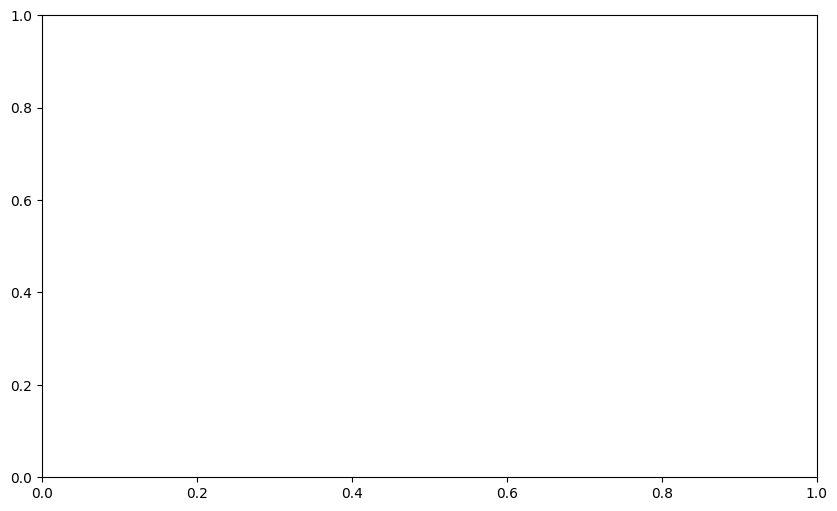

In [7]:
save_directory = './data/correct-archs/comparisons/'

def plot_and_save_graph(y_arrays, avg_value, y_label, title, filename):
    x = ptb_rate
    labels = ['gcn', 'gat', 'gsage', 'gsaint']
    plt.figure(figsize=(10, 6))
    
    for y_array, label in zip(y_arrays, labels):
        plt.plot(x, y_array, label=label)
    
    plt.axhline(y=avg_value, color='r', linestyle='--', label='CORA')
    plt.xlabel('Ptb Rates')
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    
    # Save the plot
    save_path = os.path.join(save_directory, filename)
    plt.savefig(save_path)
    plt.show()


plot_and_save_graph([deg_gcn, deg_gat, deg_gsage, deg_gsaint], degrees_avg, 'Degrees', 'Degrees vs Ptb Rates (DIFFERENCE)', 'degrees_vs_ptb_rates_dif.png')
plot_and_save_graph([homo_gcn, homo_gat, homo_gsage, homo_gsaint], homo_avg, 'Homophily', 'Homophily vs Ptb Rates (DIFFERENCE)', 'homophily_vs_ptb_rates_dif.png')
plot_and_save_graph([hop2_gcn, hop2_gat, hop2_gsage, hop2_gsaint], hop2_avg, '2-Hop Neighborhood Size', '2-Hop Neighborhood Size vs Ptb Rates (DIFFERENCE)', '2hop_vs_ptb_rates_dif.png')